# Image interp

In [120]:
import torch
import torch.nn.functional as F
from torch import pi
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

import time
import funcs

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Torch device:', DEVICE)
if str(DEVICE) == 'cuda':
    print(torch.cuda.get_device_name(torch.cuda.current_device()))

Torch device: cuda
NVIDIA GeForce RTX 3070 Laptop GPU


In [ ]:
# kernel shape : (1 + 1./step, 1+2*k)
for i, (xp, yp) in enumerate(xyp):
    u, v = int(xp+0.5), int(yp+0.5)
    dx, dy = xp-u, yp-v
    idx = int(dx / step + 0.5)
    idy = int(dy / step + 0.5)
    img_p = kernel[idy:idy+1].dot((img[u-k:u+k+1, v-k:v+k+1] @ kernel[idx]))

In [ ]:
kernel = torch.Tensor([1., 2, 3, 4, 5]) # .reshape(-1, 1)
kernel2 = torch.Tensor([7., 8, 9, 10, 11])  # .reshape((1, -1))
A = torch.arange(25, dtype=torch.float).reshape(5, 5)
print('kernel:', kernel.shape, kernel.dtype, kernel.flatten())
print('kernel2:', kernel2.shape, kernel2)
print('A:', A)



ref = A @ kernel.reshape(-1, 1)
print('ref:\n', ref)

ref = A @ kernel
print('ref:\n', ref)
# ref = kernel2 @ ref
ref = (kernel2 * ref).sum()
print('ref:\n', ref)

test = kernel2.dot(A @ kernel)
print('test:', test)
# test = torch.einsum('ij, jk -> ik', A, kernel)
# print('test:\n', test)


x: tensor([ 4,  3,  2,  1,  0, -1, -2, -3, -4])
tensor([[ 4.0000,  3.0000,  2.0000,  ..., -2.0000, -3.0000, -4.0000],
        [ 4.0010,  3.0010,  2.0010,  ..., -1.9990, -2.9990, -3.9990],
        [ 4.0020,  3.0020,  2.0020,  ..., -1.9980, -2.9980, -3.9980],
        ...,
        [ 4.4980,  3.4980,  2.4980,  ..., -1.5020, -2.5020, -3.5020],
        [ 4.4990,  3.4990,  2.4990,  ..., -1.5010, -2.5010, -3.5010],
        [ 4.5000,  3.5000,  2.5000,  ..., -1.5000, -2.5000, -3.5000]],
       dtype=torch.float64)


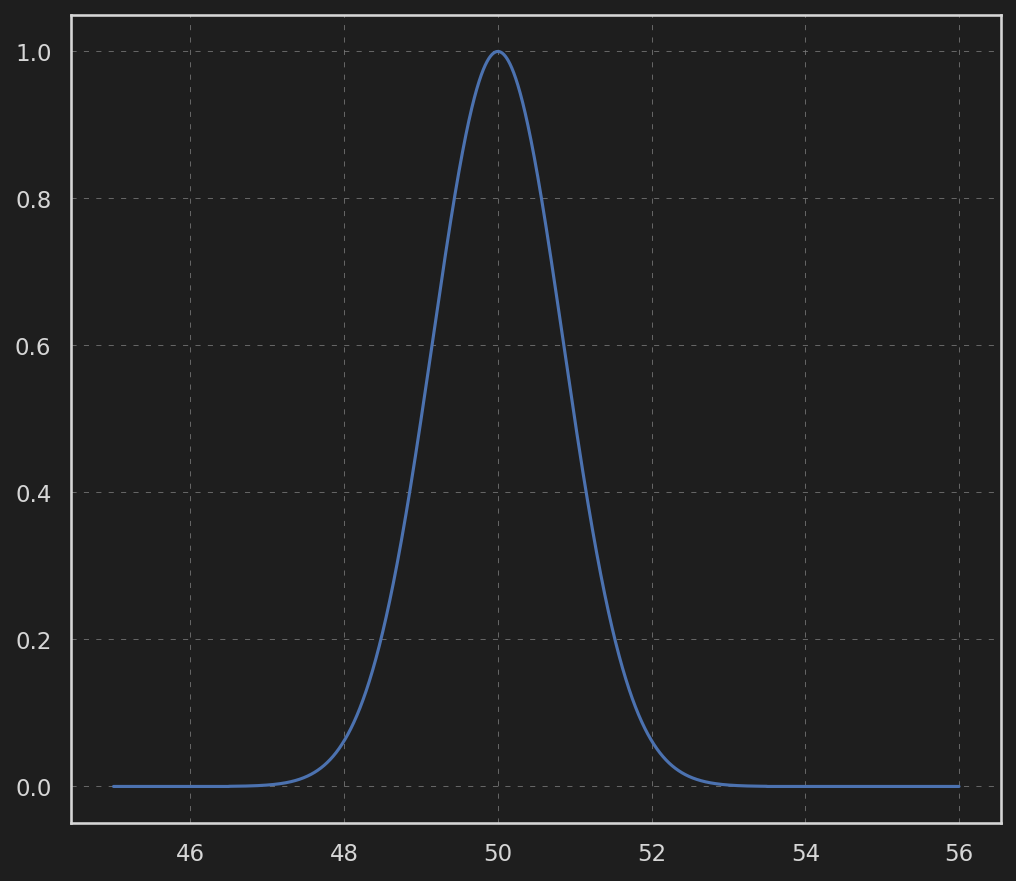

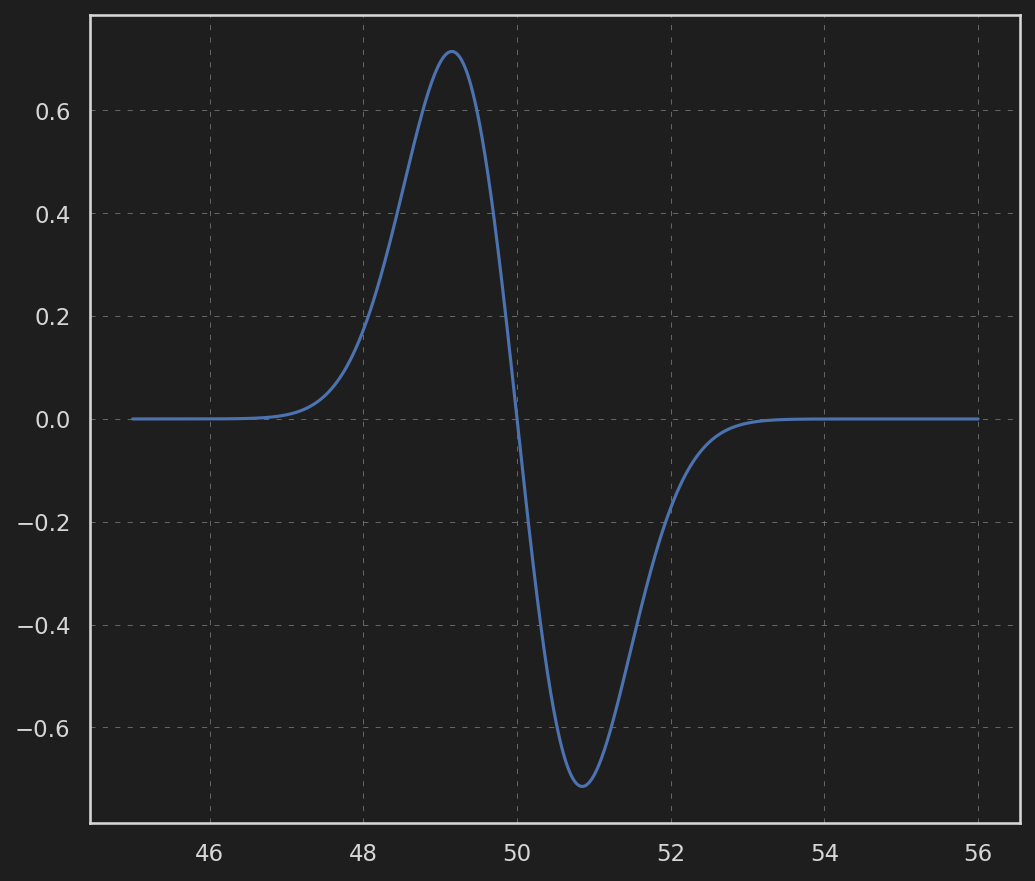

In [121]:
import torch
import matplotlib.pyplot as plt

size = 7
n = size//2
x = torch.arange(n+1, -n-1-1, -1)
print('x:', x)
dx0 = 1e-3
dx = np.arange(0, 0.5+dx0, dx0)
xdx = x.reshape(1, -1) + dx.reshape(-1, 1)
print(xdx)

sigma = 1.2
kernels = torch.exp(-(xdx*xdx) / (sigma**2))
kernels_dx = (-2*xdx/(sigma**2) * kernels)
kernels = kernels[:, 1:-1].float()
kernels_dx = kernels_dx.float()

y = torch.zeros(101)
y[50] = 1.

def interp(y, x):
    x0 = int(x + 0.5)
    dx = x - x0
    x0 -= n
    if dx < 0:
        dx = abs(dx)
        kernel = kernels[int(dx/dx0+0.5)].flip(0)
        return  kernel.dot(y[x0: x0+size])
    kernel = kernels[int(dx/dx0+0.5)]
    return kernel.dot(y[x0: x0+size])

def interp_dx(y, x):
    x0 = int(x + 0.5)
    dx = x - x0
    x0 -= n+1
    if dx < 0:
        dx = abs(dx)
        kernel = -kernels_dx[int(dx/dx0+0.5)].flip(0)
        return  kernel.dot(y[x0: x0+size+2])
    kernel = kernels_dx[int(dx/dx0+0.5)]
    return kernel.dot(y[x0: x0+size+2])

x_interp = torch.arange(45, 56, dx0)
y_interp = [interp(y, xi) for xi in x_interp]

x2 = torch.arange(45, 56)
y2 = torch.exp( -(x2-50)**2/sigma**2)
if True:
    fig, ax = plt.subplots(figsize=(8,7))
    # ax.plot(x2, y2, 'o')
    # ax.plot(xdx[:, 1:-1].flatten() + 50, kernels.flatten(), 'o')
    # ax.plot(x2, y[x2], 'o')
    ax.plot( x_interp, y_interp)

y_dx_interp = [interp_dx(y, xi) for xi in x_interp]

y2_dx = -(x2-50)/sigma**2 * y2
fig, ax = plt.subplots(figsize=(8,7))
# ax.plot( xdx.flatten() + 50, kernels_dx.flatten(), 'o')
# ax.plot(x2, y2_dx, 'o')
ax.plot( x_interp, y_dx_interp)

## Save kernels

In [138]:
import torch

size = 7
n = size//2
x = torch.arange(n+1, -n-1-1, -1)
print('x:', x)
dx0 = 1e-5
dx = np.arange(0, 0.5+dx0, dx0)
xdx = x.reshape(1, -1) + dx.reshape(-1, 1)

sigma = 1.2
kernels = torch.exp(-(xdx*xdx) / (sigma**2))

print('xdx:', xdx.shape)
print('kernels:', kernels.shape)
# kernels_dx = (-xdx/(sigma**2) * kernels)
# print('kernels_dx:\n', kernels_dx[:2])

kernels_dx = (-2*xdx[0]/(sigma**2) * kernels[0])
print('kernels_dx:', kernels_dx.shape)


kernels = kernels[:, 1:-1].float()
kernels_dx = kernels_dx.float()

funcs.to_pickle('data/interp_kernels', (kernels, kernels_dx, dx0))

x: tensor([ 4,  3,  2,  1,  0, -1, -2, -3, -4])
xdx: torch.Size([50001, 9])
kernels: torch.Size([50001, 9])
kernels_dx: torch.Size([9])


## test kernels

In [ ]:
kernels, kernels_dx, dx0 = funcs.load_pickle('data/interp_kernels')
print('kernels:', kernels.shape)
print('kernels_dx:', kernels_dx.shape)
print('dx0:', dx0)
size = kernels.shape[1]
n = size//2

kernels_dx /= kernels[0].sum()
kernels /= kernels[0].sum()
# kerenels are from 0 to +0.5
# to improve calculation speed, as memory usage is relatively low
# use symmetry in the kernels to compute -0.5 - 0.5 kernels
kernels = torch.concat((kernels[1:].flip((0,1)), kernels))
print("kernels:", kernels.shape)


def interp(y, x):
    x0 = int(x + 0.5)
    kernel = kernels[int((x - x0 +0.5)/dx0+0.5)]
    return kernel.dot(y[x0-n: x0-n+size])

def interp_array(y, x, out=None):
    x0 = (x+0.5).int()
    i_dx = ((x-x0+0.5)/dx0+0.5).int()
    x0 -= n
    x1 = x0 + size
    if out is None:
        out = torch.empty_like(x)
    for i in torch.arange(x.shape[0]):
        out[i] = kernels[i_dx[i]].dot(y[x0[i]:x1[i]])
    return out

y = torch.zeros(20, dtype=torch.float)
y[10] = 1.
x_interp = torch.linspace(5, 15, 100000)
print('\ninterpolation...')
t0 = time.time()
y_interp = [interp(y, xi) for xi in x_interp]
print('elasped time:', funcs.chrono(time.time()-t0))

t0 = time.time()
y_interp = interp_array(y, x_interp)
print('elasped time:', funcs.chrono(time.time()-t0))

# fig, ax = plt.subplots()
# ax.plot(y, 'o')
# ax.plot(x_interp, y_interp)

In [ ]:
v_slice0 = torch.arange(-n, n+1)
y_slices, x_slices = torch.meshgrid(v_slice0, v_slice0)
print(x_slices)
print(y_slices)
# x_slices, y_slices = x_slices.flatten(), y_slices.flatten()

In [ ]:
kernels, kernels_dx, dx0 = funcs.load_pickle('data/interp_kernels')
print('kernels:', kernels.shape)
print('kernels_dx:', kernels_dx.shape)
print('dx0:', dx0)
size = kernels.shape[1]
n = size//2

# factor = torch.sqrt(kernels[0].sum())
factor = kernels[0].sum()
# factor = np.sqrt(sigma * np.sqrt(2*pi))
# factor = sigma * np.sqrt(2*pi)

kernels_dx /= factor
kernels /= factor
kernels = torch.concat((kernels[1:].flip((0,1)), kernels))


def interp_img0(img, x, y, out=None):
    x0 = (x+0.5).int()
    i_dx = ((x-x0+0.5)/dx0+0.5).int()
    x0 -= n
    x1 = x0 + size

    y0 = (y+0.5).int()
    i_dy = ((y-y0+0.5)/dx0+0.5).int()
    y0 -= n
    y1 = y0 + size
    
    if out is None:
        out = torch.empty_like(x)
    # for i in torch.arange(x.shape[0]):
    # for i in np.arange(x.shape[0]):
        out[i] = kernels[i_dy[i]].dot(
            img[y0[i]:y1[i], x0[i]:x1[i]] @ kernels[i_dx[i]]
            )
    # out[:] = kernels[i_dy].dot() 
    return out

kernels = kernels.reshape(kernels.shape[0], kernels.shape[-1], 1)
print('kernels:', kernels.shape)
def interp_img  (img, x, y, out=None):
    x0 = (x+0.5).int()
    i_dx = ((x-x0+0.5)/dx0+0.5).int()
    # x0 -= n
    # x1 = x0 + size

    y0 = (y+0.5).int()
    i_dy = ((y-y0+0.5)/dx0+0.5).int()
    # y0 -= n
    # y1 = y0 + size
    
    N = len(x0)
    out = kernels[i_dy].reshape(N, 1, 7) @ \
        (img[v_slice0.reshape(1, 7, 1) + y0.reshape(-1, 1, 1), x_slices+x0.reshape(-1, 1, 1)]
        @ kernels[i_dx])
    return out.flatten()


xmax, ymax = 60, 60
x = torch.linspace(0, 100, xmax+1)
y = torch.linspace(0, 100, ymax+1)

yy, xx = torch.meshgrid(x, y, indexing='ij')

# print('xx:\n', xx)

img = torch.cos((2*pi/30.)*xx) * torch.exp(xx*xx * (np.log(0.001)/20000))
img += torch.cos((2*pi/35.)*yy) * torch.exp(yy*yy * (np.log(0.001)/20000))

# img = torch.zeros_like(xx)
# img[n, n] = 2.
# img = transforms.GaussianBlur(7, 1.)(img.reshape((1,) + img.shape))[0]

print('img:', img.shape)




x2 = torch.linspace(n, xmax-n-2, 512)
y2 = torch.linspace(n, ymax-n-2, 512)

yy2, xx2 = torch.meshgrid(x2, y2, indexing='ij')

img2 = torch.empty(x2.shape[0]*y2.shape[0], dtype=torch.float)

if False:
    img.to(DEVICE), xx2.to(DEVICE), yy2.to(DEVICE), img2.to(DEVICE)
    kernels.to(DEVICE)
else:
    img.to('cpu'), xx2.to('cpu'), yy2.to('cpu'), img2.to('cpu')
    kernels.to('cpu')

t0 = time.time()
img2 = interp_img(img, xx2.flatten(), yy2.flatten(), img2)
print('elasped time:', funcs.chrono(time.time()-t0))
print('interp size:', img2.shape)

if True:
    fig, ax = plt.subplots()
    im = ax.imshow(img.numpy())
    fig.colorbar(im)
    
    img2 = img2.numpy().reshape(y2.shape[0], x2.shape[0])


    fig, ax = plt.subplots()
    im = ax.imshow(img2)
    fig.colorbar(im)

    ref_x = img[int(y2[0].item()+0.5), :]
    ref_y = img[:, int(x2[0].item()+0.5)]

    fig, axs = plt.subplots(nrows=2)
    axs[0].plot(ref_x, 'o')
    axs[0].plot(x2, img2[0, :])

    axs[1].plot(ref_y, 'o')
    axs[1].plot(y2, img2[:, 0])

# Image Generation

In [ ]:
shape = (512, 512)
img = torch.zeros(shape, dtype=torch.uint8)


xc, yc = 110.9, 300.6 
rx, ry = 3, 2
tta = pi * 0.1
value = 220
y0, x0 = torch.meshgrid(torch.arange(-4, 5), torch.arange(-4, 5))
x0, y0 = x0.flatten(), y0.flatten()
xy0 = torch.stack((x0, y0)).float()

def generate_speckle(img):
    img[:, :] = 0.

    
    # print(xy0.shape)

    Rot = torch.tensor(
        [[np.cos(tta), -np.sin(tta)],
        [np.sin(tta), np.cos(tta)]], dtype=torch.float)

    dx = xc - int(xc)
    dy = yc - int(yc)
    xy1 = Rot @ (xy0 - torch.tensor([[dx], [dy]]))
    b_in = (xy1[0]**2 / rx**2 + xy1[1]**2 / ry**2) < 1.
    img[y0[b_in]+int(yc), x0[b_in]+int(xc)] = int(value)
    return
generate_speckle(img)


v_tta = np.linspace(0, pi+pi, 33)
fig, ax = plt.subplots()
ax.imshow(img)
ax.plot(xc, yc, 'ro')
ax.plot(x0[b_in]+int(xc), y0[b_in]+int(yc), 'bo')
ax.plot(
    xc+rx*np.cos(v_tta), yc+rx*np.sin(v_tta)
)
ax.plot(
    xc+ry*np.cos(v_tta), yc+ry*np.sin(v_tta)
)
ax.set_xlim([xc-5, xc+5])
ax.set_ylim([yc-5, yc+5])


In [ ]:
help(F.avg_pool2d)

In [ ]:
1./ 16

In [ ]:
scale = 4

img = torch.zeros((8, 8), dtype=torch.float)
img[1,1] = 1.
print(img)
F.avg_pool2d(img.reshape((1,) + img.shape), kernel_size=scale, stride=scale, padding=1)[0]


In [ ]:
shape = (512, 512)
scale = 4


def generate_speckles(img, n_ell, rmin, rmax, graymax):
    shape = torch.tensor(img.shape)

    values = torch.rand((6, n_ell))
    xyc = values[:2] * shape.reshape(2, 1)
    rxy = rmin + values[2:4] * (rmax-rmin)
    tta = values[4] * (pi*0.5)
    grayscale = 0.008 + values[5] * graymax

    dxy = xyc - xyc.int()
    cos_tta = torch.cos(tta)
    sin_tta = torch.sin(tta)
    Rot = torch.empty((n_ell, 2, 2))
    # Rot[:, [0, 0], [1, 1]] = cos_tta.reshape(-1, 1)
    Rot[:, 0, 0] = cos_tta
    Rot[:, 1, 1] = cos_tta
    Rot[:, 0, 1] = -sin_tta
    Rot[:, 1, 0] = sin_tta

    nmax = int(rmax+1.5)
    y0, x0 = torch.meshgrid(
        torch.arange(-nmax, nmax+1), torch.arange(-nmax, nmax+1), indexing='ij'
    )
    x0, y0 = x0.flatten(), y0.flatten()
    xy0 = torch.stack((x0, y0)).float()

    # print(xy0.shape)
    for i in np.arange(n_ell):
        # Rot = torch.tensor(
        #     [[np.cos(tta[i]), -np.sin(tta[i])],
        #     [np.sin(tta[i]), np.cos(tta[i])]], dtype=torch.float)

        xy1 = Rot[i] @ (xy0 - dxy[:,i:i+1])
        b_in = (xy1**2 / rxy[:, i:i+1]**2).sum(0) < 1.
        # print('y0:', y0.shape)
        # b_in = (xy1[0]**2 / rxy[0,i]**2 + xy1[1]**2 / ry[i]**2) < 1.
        y = y0[b_in]+int(xyc[1, i])
        x = x0[b_in]+int(xyc[0, i])
        b_ok = (y > -1) & (y < shape[0]) & (x > -1) & (x < shape[1])
        img[y[b_ok], x[b_ok]] = grayscale[i]

    return


def generate_image(shape, scale, sparse, largeSpeckles, lowContrast):
    img = torch.zeros(tuple(n*scale for n in shape), dtype=torch.float)
    factor = shape[0] * shape[1] / 512**2
    n_ell = torch.randint(
        low=int(2800*factor),
        high=int(4500*factor),
        size=(1,)
    ).item()

    # rmin = 0.6 * scale
    # rmax = (1.75 if sparse else 3.4) * scale
    rmin = 1.2 * scale
    rmax = (3.5 if sparse else 6.8) * scale
    graymax = 0.6 if lowContrast else 0.9

    generate_speckles(img, n_ell, rmin, rmax, graymax)
    if largeSpeckles:
        n_ell = torch.randint(
            low=max(1, int(factor + 0.5)),
            high=max(5, int(factor*5 +0.5)),
            size=(1,)
        ).item()
        rmin = 6.5 * scale
        rmax = 10.5 * scale
        generate_speckles(img, n_ell, rmin, rmax, graymax)

    img = F.avg_pool2d(img.reshape((1,) + img.shape), kernel_size=scale, stride=scale, padding=0)[0]
    img = transforms.functional.gaussian_blur(img.reshape((1,) + img.shape), 5)[0]
    return img


sparse = False
largeSpeckles = True
lowContrast = False

t0 = time.time()
img = generate_image(shape, scale, sparse, largeSpeckles, lowContrast)
print('elapsed time:', funcs.chrono(time.time()-t0))

fig, ax = plt.subplots()
ax.imshow(img, cmap='gray')
_ = ax.axis('off')
# ax.set_xlim([20, 160])
# ax.set_ylim([20, 160])


# Hermite2dD

In [ ]:
t = torch.arange(12).reshape(3, 4)

print(t)
print(t @ torch.arange(4))
t @ torch.arange(4).reshape(-1, 1)

In [ ]:
import Hermite
import importlib

In [ ]:
importlib.reload(Hermite)

In [ ]:
importlib.reload(Hermite)

elementSizes = [5, 9, 17, 33, 65]
maxDisps = [1., 1., 2., 3., 4.]

shape = (128, 128)
case = 2
maxDisp = maxDisps[case]
elementSize = elementSizes[case]
nNodes = tuple(1+n//(elementSize-1) for n in shape)
t0 = time.time()
out = Hermite.Hermite2D(maxDisp, nNodes, elementSize, shape)
print('elapsed time:', time.time()-t0)
out.shape

In [ ]:
if True:
    fig, ax = plt.subplots()
    im = ax.imshow(out[0])
    fig.colorbar(im)

    fig, ax = plt.subplots()
    im = ax.imshow(out[1])
    fig.colorbar(im)

    fig, ax = plt.subplots()
    im = ax.imshow(out[0, :, 1:]-out[0, :, :-1])
    fig.colorbar(im)

    fig, ax = plt.subplots()
    im = ax.imshow(out[2])
    fig.colorbar(im)

    fig, ax = plt.subplots()
    im = ax.imshow(out[0, 1:, :]-out[0, :-1, :])
    fig.colorbar(im)

if True:
    fig, ax = plt.subplots()
    im = ax.imshow(out[3])
    fig.colorbar(im)

    fig, ax = plt.subplots()
    im = ax.imshow(out[4])
    fig.colorbar(im)

    fig, ax = plt.subplots()
    im = ax.imshow(out[3, :, 1:]-out[3, :, :-1])
    fig.colorbar(im)

    fig, ax = plt.subplots()
    im = ax.imshow(out[5])
    fig.colorbar(im)

    fig, ax = plt.subplots()
    im = ax.imshow(out[3, 1:, :]-out[3, :-1, :])
    fig.colorbar(im)

# image pair

In [139]:
import time
import importlib
import matplotlib.pyplot as plt
import torch

import Hermite
import dic_tools as dic
import funcs

kernels: torch.Size([50001, 7])
kernel_dx: torch.Size([9])
dx0: 1e-05
kernels: torch.Size([100001, 7])
kernels: torch.Size([100001, 7, 1])
elapsed time: 00:00:00.97
Hermite : elapsed time: 0.0016367435455322266
out: torch.Size([6, 128, 128])
u2 : elapsed time: 0.00010943412780761719
img: torch.Size([512, 512])
Interp : elapsed time: 0.0004901885986328125


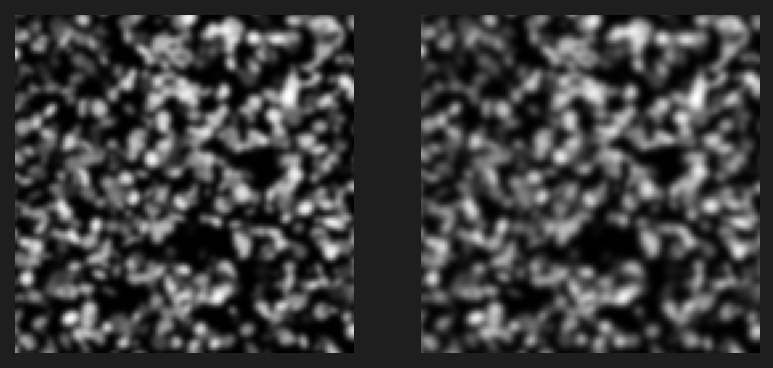

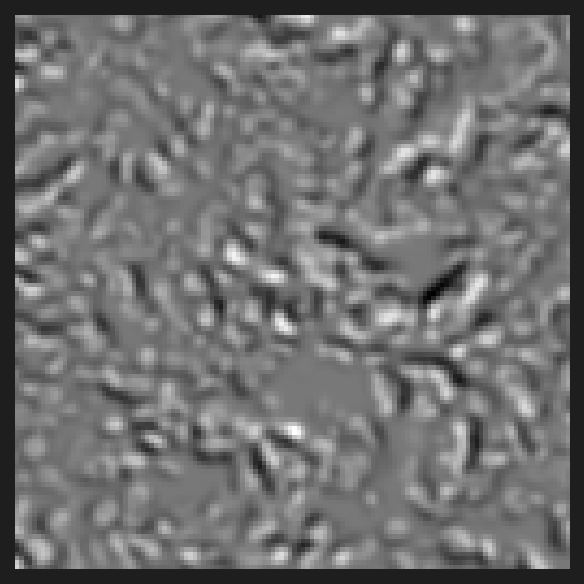

In [166]:
importlib.reload(dic)

shape = (512, 512)
scale = 4

sparse = False
largeSpeckles = False
lowContrast = False

torch.manual_seed(0)
t0 = time.time()
for i in range(1):
    img = dic.generate_image(shape, scale, sparse, largeSpeckles, lowContrast)
print('elapsed time:', funcs.chrono(time.time()-t0))


case = 3
t0 = time.time()
for i in range(1):
    out = Hermite.Hermite2d_case(case)
print('Hermite : elapsed time:', time.time()-t0)
print('out:', out.shape)

u0, v0 = 32, 50
t0 = time.time()
for i in range(1):
    u2, v2 = u0 + Hermite.UU + out[0].ravel(), v0 + Hermite.VV + out[3].ravel()
print('u2 : elapsed time:', time.time()-t0)

print('img:', img.shape)
t0 = time.time()
for i in range(1):
    img_ref = dic.interp_img(img.to(dic.DEVICE), u2, v2)
    # img_ref = dic.interp_img(img, u2, v2)
print('Interp : elapsed time:', time.time()-t0)

img = img[v0:v0 + out.shape[-2], u0:u0 + out.shape[-1]]
img_ref = img_ref.reshape(img.shape).to('cpu')

fig, axs = plt.subplots(ncols=2)
axs[0].imshow(img, cmap='gray')
_ = axs[0].axis('off')

axs[1].imshow(img_ref, cmap='gray')
_ = axs[1].axis('off')

fig, ax = plt.subplots()
ax.imshow(img-img_ref, cmap='gray')
_ = ax.axis('off')

# ax.set_xlim([0, 128])
# ax.set_ylim([128, 0])

In [193]:
importlib.reload(dic)

u0, v0 = 60.5, 62.5
size = 20
correlator = dic.Correlator(img_ref, size, u0, v0)
uv = correlator.get_uv().to('cpu')

kernels: torch.Size([50001, 7])
kernel_dx: torch.Size([9])
dx0: 1e-05
kernels: torch.Size([100001, 7])
kernels: torch.Size([100001, 7, 1])


dp:
 tensor([[-2.8433e-06,  1.0000e+00,  2.0223e-06,  1.4965e-07, -1.7174e-07,
          1.1484e-07],
        [ 6.5137e-06,  1.2470e-06,  1.0000e+00, -2.5188e-07,  3.2008e-07,
         -1.6409e-07]], device='cuda:0')


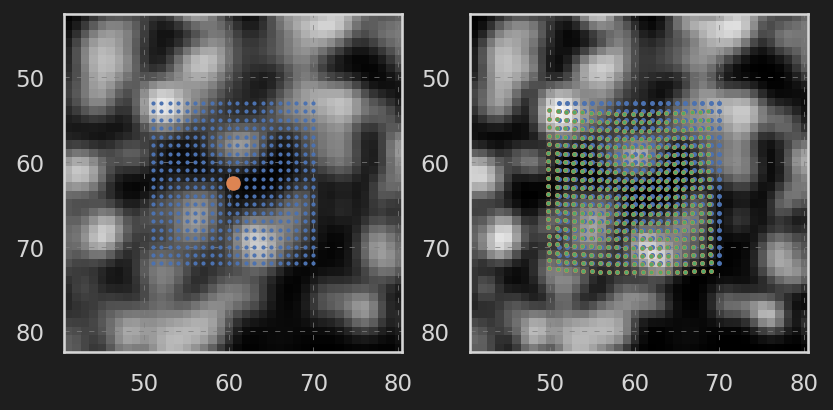

In [203]:
# dp = correlator.estim_dp(img.to(dic.DEVICE))
dp = correlator.estim_dp(img.to(dic.DEVICE))
print('dp:\n', dp)
uv2 = correlator.compute_p_dp(dp).to('cpu')
# print('\nuv2:\n', uv2[:, :3])
correlator.update_p(dp)
uv3 = correlator.get_uv().to('cpu')

fig, axs = plt.subplots(ncols=2)
ax = axs[0]
ax.imshow(img_ref, cmap='gray')
ax.plot(uv[0], uv[1], 'o', markersize=1)
ax.plot([u0], [v0], 'o')
ax.set_xlim([u0-size, u0+size])
ax.set_ylim([v0+size, v0-size])


ax = axs[1]
ax.imshow(img, cmap='gray')
ax.plot(uv[0], uv[1], 'o', markersize=1.4)
ax.plot(uv2[0], uv2[1], 'o', markersize=1.4)
ax.plot(uv3[0], uv3[1], 'o', markersize=1)
# ax.plot([u0], [v0], 'o')
ax.set_xlim([u0-size, u0+size])
_ = ax.set_ylim([v0+size, v0-size])

In [44]:
help(torch.mean)

Help on built-in function mean in module torch:

mean(...)
    mean(input, *, dtype=None) -> Tensor
    
    Returns the mean value of all elements in the :attr:`input` tensor.
    
    Args:
        input (Tensor): the input tensor.
    
    Keyword args:
        dtype (:class:`torch.dtype`, optional): the desired data type of returned tensor.
            If specified, the input tensor is casted to :attr:`dtype` before the operation
            is performed. This is useful for preventing data type overflows. Default: None.
    
    Example::
    
        >>> a = torch.randn(1, 3)
        >>> a
        tensor([[ 0.2294, -0.5481,  1.3288]])
        >>> torch.mean(a)
        tensor(0.3367)
    
    .. function:: mean(input, dim, keepdim=False, *, dtype=None, out=None) -> Tensor
       :noindex:
    
    Returns the mean value of each row of the :attr:`input` tensor in the given
    dimension :attr:`dim`. If :attr:`dim` is a list of dimensions,
    reduce over all of them.
    
    
    I

# Check Ix Iy

kernels: torch.Size([50001, 7])
kernel_dx: torch.Size([9])
dx0: 1e-05
kernels: torch.Size([100001, 7])
kernels: torch.Size([100001, 7, 1])

Ix2: tensor(0.0029) tensor(-0.2052) tensor(0.2101)
Ix: tensor(0.0032) tensor(-0.2226) tensor(0.2322)

Iy2: tensor(0.0030) tensor(-0.2149) tensor(0.2190)
Iy: tensor(0.0033) tensor(-0.2310) tensor(0.2369)


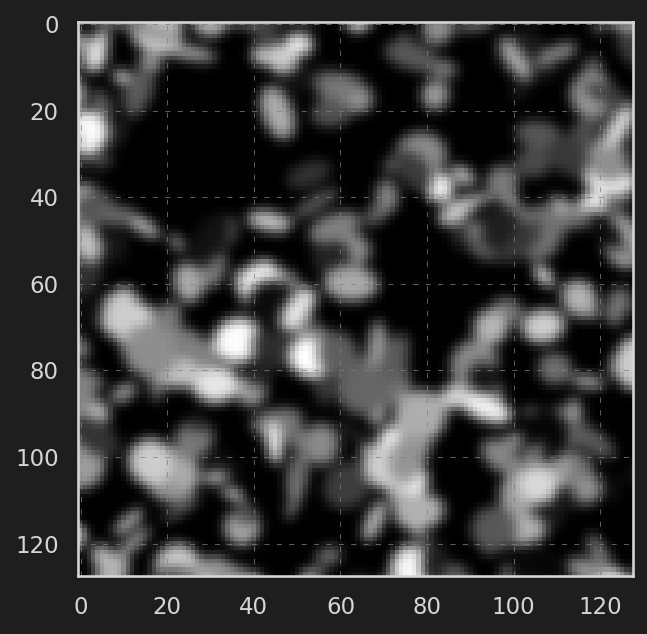

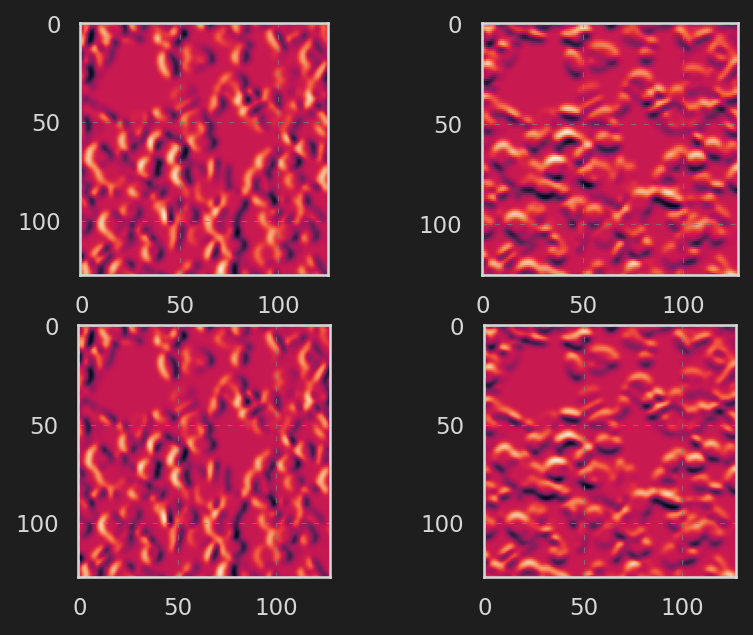

In [149]:
importlib.reload(dic)
importlib.reload(Hermite)

torch.manual_seed(0)
img = dic.generate_image(shape, scale, sparse, largeSpeckles, lowContrast)
shape = img.shape
u0, v0 = 32, 50
u, v = u0 + Hermite.UU, v0 + Hermite.VV
Ix, Iy = dic.dxy_img(img.to(dic.DEVICE), u.ravel(), v.ravel())

img = dic.interp_img(img.to(dic.DEVICE), u.ravel(), v.ravel()).reshape((128,128)).to('cpu')
Ix, Iy = Ix.to('cpu'), Iy.to('cpu')

# img = img[v0: v0+128, u0: u0+128]

fig, ax = plt.subplots()
ax.imshow(img, cmap='gray')
ax.grid('off')

Ix2 = (img[:, 2:]-img[:, :-2]) * 0.5
Iy2 = (img[2:]-img[:-2]) * 0.5
fig, axs = plt.subplots(nrows=2, ncols=2)
axs[0][0].imshow(Ix2)
axs[0][1].imshow(Iy2)
axs[1][0].imshow(Ix.reshape(img.shape))
axs[1][1].imshow(Iy.reshape(img.shape))

print('\nIx2:', torch.abs(Ix2*Ix2).mean(), Ix2.min(), Ix2.max())
print('Ix:', torch.abs(Ix*Ix).mean(), Ix.min(), Ix.max())

print('\nIy2:', torch.abs(Iy2*Iy2).mean(), Iy2.min(), Iy2.max())
print('Iy:', torch.abs(Iy*Iy).mean(), Iy.min(), Iy.max())

(tensor([[0, 0, 0, 0],
         [1, 1, 1, 1],
         [2, 2, 2, 2]]),
 tensor([[0, 1, 2, 3],
         [0, 1, 2, 3],
         [0, 1, 2, 3]]))

In [ ]:
vj = torch.arange(nNodes[1]-1, device=DEVICE)
flatten -> ravel